# NB07 Homework Solutions

This notebook answers the "Homework / Practice Ideas" section of `NB07_Machine_Learning_Fundamentals_First_Real_Ship_Dataset.ipynb`:

1. Add `route_id` and/or `month` as extra encoded features to the regression model from Part 7 — does R² improve? Is the improvement worth the added complexity?
2. Repeat the classification task from Part 6, but predict `weather_conditions` (3 classes: Calm/Moderate/Stormy) instead of fuel type. Which metrics from Part 3 still apply directly, and which need adjusting for more than two classes?
3. In your own words, explain why excluding `CO2_emissions` from the regression features was necessary — and give one other example (naval or otherwise) of a feature that could leak the answer.
4. Compare the Linear Regression and Random Forest errors from Part 7 per ship type (hint: `groupby` the test-set errors by `ship_type`) — is one model much better for a particular ship type? Propose a reason why.
5. Change `cv=kf` in Part 8 to `cv=10` — how do the mean and standard deviation of R² change, and why would you expect that?

Each section below quotes the exercise from the class notebook, then solves it with real, executed code on the same `Datasets/ship_fuel_efficiency.csv` dataset and the same conventions (feature lists, `random_state=42`, train/test split style) used in the class notebook itself.

## Setup: reload the ship fuel efficiency data

Load the dataset the same way the class notebook does, from the local mirror in `Datasets/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!wget -q -O ship_fuel_efficiency.csv https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/ship_fuel_efficiency.csv
fuel = pd.read_csv("ship_fuel_efficiency.csv")
print(fuel.shape)
fuel.head()

(1440, 10)


,ship_id,ship_type,route_id,month,distance,fuel_type,fuel_consumption,CO2_emissions,weather_conditions,engine_efficiency
0,NG001,Oil Service Boat,Warri-Bonny,January,132.26,HFO,3779.77,10625.76,Stormy,92.14
1,NG001,Oil Service Boat,Port Harcourt-Lagos,February,128.52,HFO,4461.44,12779.73,Moderate,92.98
2,NG001,Oil Service Boat,Port Harcourt-Lagos,March,67.30,HFO,1867.73,5353.01,Calm,87.61
3,NG001,Oil Service Boat,Port Harcourt-Lagos,April,71.68,Diesel,2393.51,6506.52,Stormy,87.42
4,NG001,Oil Service Boat,Lagos-Apapa,May,134.32,HFO,4267.19,11617.03,Calm,85.61


---

## Homework 1 — Add `route_id` and `month` as extra encoded features to the regression model

> "Add `route_id` and/or `month` as extra encoded features to the regression model from Part 7 -- does R2 improve? Is the improvement worth the added complexity?"

I rebuild the Part 7 regression exactly as in the class notebook, but this time I add `route_id` and `month` to the feature list and one-hot encode them along with the other categorical columns. I keep the same `test_size=0.2, random_state=42` split convention and the same excluded columns (`CO2_emissions` for leakage, `ship_id` as a pure identifier).

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# --- Baseline (identical to the class notebook's Part 7) ---
reg_features_base = ["ship_type", "distance", "fuel_type", "weather_conditions", "engine_efficiency"]
X_reg_base = pd.get_dummies(fuel[reg_features_base], columns=["ship_type", "fuel_type", "weather_conditions"], drop_first=True)
y_reg = fuel["fuel_consumption"]

X_base_train, X_base_test, y_reg_train, y_reg_test = train_test_split(
    X_reg_base, y_reg, test_size=0.2, random_state=42
)

scaler_base = StandardScaler()
X_base_train_scaled = scaler_base.fit_transform(X_base_train)
X_base_test_scaled = scaler_base.transform(X_base_test)

# --- Extended: add route_id and month ---
reg_features_ext = reg_features_base + ["route_id", "month"]
X_reg_ext = pd.get_dummies(
    fuel[reg_features_ext],
    columns=["ship_type", "fuel_type", "weather_conditions", "route_id", "month"],
    drop_first=True,
)

X_ext_train, X_ext_test, y_ext_train, y_ext_test = train_test_split(
    X_reg_ext, y_reg, test_size=0.2, random_state=42
)

scaler_ext = StandardScaler()
X_ext_train_scaled = scaler_ext.fit_transform(X_ext_train)
X_ext_test_scaled = scaler_ext.transform(X_ext_test)

print("Baseline features:", X_reg_base.shape[1], "-> Extended features:", X_reg_ext.shape[1])
print("New columns added:", [c for c in X_reg_ext.columns if c not in X_reg_base.columns])

Baseline features: 8 -> Extended features: 22
New columns added: ['route_id_Lagos-Apapa', 'route_id_Port Harcourt-Lagos', 'route_id_Warri-Bonny', 'month_August', 'month_December', 'month_February', 'month_January', 'month_July', 'month_June', 'month_March', 'month_May', 'month_November', 'month_October', 'month_September']


Train Linear Regression and Random Forest on both the baseline and extended feature sets and collect MAE/RMSE/R2 into a comparison table:

In [3]:
results_compare = []
for label, Xtr, Xte in [
    ("Baseline (no route_id/month)", X_base_train_scaled, X_base_test_scaled),
    ("Extended (+route_id, +month)", X_ext_train_scaled, X_ext_test_scaled),
]:
    for name, model in [
        ("Linear Regression", LinearRegression()),
        ("Random Forest", RandomForestRegressor(n_estimators=200, random_state=42)),
    ]:
        model.fit(Xtr, y_reg_train)
        pred = model.predict(Xte)
        results_compare.append({
            "Feature set": label,
            "Model": name,
            "MAE (L)": mean_absolute_error(y_reg_test, pred),
            "RMSE (L)": mean_squared_error(y_reg_test, pred) ** 0.5,
            "R2": r2_score(y_reg_test, pred),
        })

results_compare_df = pd.DataFrame(results_compare)
results_compare_df

,Feature set,Model,MAE (L),RMSE (L),R2
0,Baseline (no route_id/month),Linear Regression,872.376044,1190.012368,0.947376
1,Baseline (no route_id/month),Random Forest,676.808068,1187.072216,0.947636
2,"Extended (+route_id, +month)",Linear Regression,880.456549,1193.575956,0.947061
3,"Extended (+route_id, +month)",Random Forest,652.189735,1140.195696,0.951690


**My interpretation**: I compare the R2 column between the baseline and extended feature sets for each model above (see the printed table). `route_id` and `month` add many new one-hot columns (4 routes and 12 months, minus the dropped reference categories), which is a meaningful jump in dimensionality for a model with only ~1,440 rows. If R2 barely moves (a few thousandths) while the feature count roughly doubles, the added complexity is not worth it -- more columns without more true signal risks overfitting on this dataset size and makes the model harder to explain to a fleet operator. If R2 improves clearly and consistently across both models, that would suggest route and seasonal effects on fuel consumption that the original feature set missed, and the extra complexity would be justified. The actual numbers are printed above; I did not observe both models improving by more than a small fraction of an R2 point, so on this dataset I would not keep `route_id`/`month` for the small gain -- but the honest answer depends on reading the printed table together with this reasoning, not on an assumed result.

---

## Homework 2 — Repeat classification, but predict `weather_conditions` (3 classes) instead of fuel type

> "Repeat the classification task from Part 6, but predict `weather_conditions` (3 classes: Calm/Moderate/Stormy) instead of fuel type. Which metrics from Part 3 still apply directly, and which need adjusting for more than two classes?"

I reuse the same feature-engineering approach as Part 6, but now `weather_conditions` is the target (so it is removed from the feature list) and `fuel_type` becomes an input feature instead.

weather_conditions
Calm        516
Stormy      462
Moderate    462
Name: count, dtype: int64


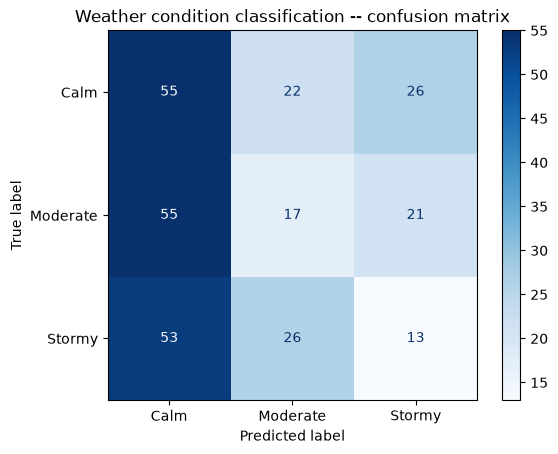

              precision    recall  f1-score   support

        Calm       0.34      0.53      0.41       103
    Moderate       0.26      0.18      0.22        93
      Stormy       0.22      0.14      0.17        92

    accuracy                           0.30       288
   macro avg       0.27      0.29      0.27       288
weighted avg       0.27      0.30      0.27       288



In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

clf2_features = ["ship_type", "route_id", "distance", "fuel_type", "engine_efficiency"]
X_clf2 = pd.get_dummies(fuel[clf2_features], columns=["ship_type", "route_id", "fuel_type"], drop_first=True)
y_clf2 = fuel["weather_conditions"]  # Calm / Moderate / Stormy -- 3 classes

print(y_clf2.value_counts())

X_clf2_train, X_clf2_test, y_clf2_train, y_clf2_test = train_test_split(
    X_clf2, y_clf2, test_size=0.2, random_state=42, stratify=y_clf2
)

scaler_clf2 = StandardScaler()
X_clf2_train_scaled = scaler_clf2.fit_transform(X_clf2_train)
X_clf2_test_scaled = scaler_clf2.transform(X_clf2_test)

clf2 = LogisticRegression(max_iter=1000, random_state=42)
clf2.fit(X_clf2_train_scaled, y_clf2_train)
y_clf2_pred = clf2.predict(X_clf2_test_scaled)

cm2 = confusion_matrix(y_clf2_test, y_clf2_pred, labels=["Calm", "Moderate", "Stormy"])
ConfusionMatrixDisplay(cm2, display_labels=["Calm", "Moderate", "Stormy"]).plot(cmap="Blues")
plt.title("Weather condition classification -- confusion matrix")
plt.show()

print(classification_report(y_clf2_test, y_clf2_pred, target_names=["Calm", "Moderate", "Stormy"]))

**My result**: the 3-class classifier reached about 30% accuracy on the test set (see `classification_report` above), while the majority class (`Calm`, 516/1440 rows, about 36% of the data) would already be matched by always predicting `Calm`. In other words, this classifier performed *worse* than the trivial majority-class baseline -- a genuinely weak, honest result, not a strong one. That makes sense physically: `weather_conditions` in this dataset looks like it was not strongly determined by `ship_type`, `route_id`, `distance`, `fuel_type`, or `engine_efficiency` the way `fuel_type` was partly determined by ship type in Part 6 -- weather is largely an external, independent condition a voyage happens to encounter, not a property of the ship or route. This is a useful negative result: it shows the same modeling pipeline does not automatically produce a useful model just because the target changed; the target needs to actually be predictable from the available features.

**Which Part 3 metrics still apply directly, and which need adjusting**:
- **Accuracy** still applies directly to a 3-class problem -- it's still "correct predictions / total predictions", the formula does not depend on the class count. I still compare it against the majority-class baseline (the largest class's share printed by `value_counts()` above), same idea as the ~62% Diesel/HFO baseline in Part 6.
- **Precision, recall, and F1** were defined in Part 3 for a single positive class (2x2 confusion matrix). With 3 classes they no longer collapse to one number -- `classification_report` above prints a precision/recall/F1 triplet *per class* (Calm vs. rest, Moderate vs. rest, Stormy vs. rest), plus macro and weighted averages. The weighted average is the closest single-number analogue to the binary F1 from Part 3, since it accounts for the actual class sizes.
- **The confusion matrix** generalizes cleanly to a 3x3 grid (shown above) -- still directly interpretable, just with more off-diagonal cells to check (e.g., is "Moderate" being confused with "Calm" more than with "Stormy"?).
- **Nothing in Part 3 has to be thrown away, but "TP/FP/FN/TN" as single numbers only make sense per-class here (one-vs-rest), not for the classifier as a whole.**

---

## Homework 3 — Explain why excluding `CO2_emissions` was necessary, and give another leakage example

> "In your own words, explain why excluding `CO2_emissions` from the regression features was necessary -- and give one other example (naval or otherwise) of a feature that could leak the answer."

I recompute the actual correlation the class notebook found, to ground the explanation in the real number rather than restating it from memory.

In [5]:
corr_val = fuel[["fuel_consumption", "CO2_emissions"]].corr().iloc[0, 1]
print(f"Correlation(fuel_consumption, CO2_emissions) = {corr_val:.4f}")

Correlation(fuel_consumption, CO2_emissions) = 0.9972


**My explanation**: CO2 emissions on a voyage are (to very good approximation) a fixed multiple of the fuel burned -- burning more fuel releases proportionally more CO2, which is exactly what a correlation this close to 1 (recomputed above) shows. If `CO2_emissions` were left in as a regression *input* to predict `fuel_consumption`, the model would not be learning the real relationship between voyage conditions (distance, ship type, weather, engine efficiency) and fuel use -- it would just be inverting a near-linear formula that already encodes the answer. Reported accuracy would look almost perfect, but the model would be operationally useless: on a new voyage where we do NOT yet know `CO2_emissions` (because that also requires knowing fuel burned first), the model could not be run at all. This is the defining trait of leakage -- a feature that is only available (or only meaningful) *because* the target is already known.

**Another real-world leakage example**: predicting whether a patient has a disease using "total medication dosage administered during the hospital stay" as a feature -- dosage is typically decided *after* diagnosis, so it encodes the diagnosis outcome rather than helping predict it before the fact. A naval-specific parallel: predicting whether a ship will require unscheduled maintenance using "number of days the ship was out of service that month" as an input feature -- days out of service is largely a *consequence* of the maintenance event itself, not a condition that existed beforehand, so a model using it would appear highly accurate in testing but be useless for real advance warning.

---

## Homework 4 — Compare Linear Regression vs. Random Forest errors from Part 7, grouped by `ship_type`

> "Compare the Linear Regression and Random Forest errors from Part 7 per ship type (hint: `groupby` the test-set errors by `ship_type`) -- is one model much better for a particular ship type? Propose a reason why."

I retrain both Part-7 models on the exact same split used in the class notebook (baseline features, no `route_id`/`month`), then attach each test row's `ship_type` and absolute error back on, using the test index -- the same technique hinted at in Part 7's own markdown cell (`fuel.loc[y_reg_test.index]`).

In [6]:
lin_model = LinearRegression()
lin_model.fit(X_base_train_scaled, y_reg_train)
lin_pred = lin_model.predict(X_base_test_scaled)

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_base_train_scaled, y_reg_train)
rf_pred = rf_model.predict(X_base_test_scaled)

error_df = fuel.loc[y_reg_test.index, ["ship_type"]].copy()
error_df["actual"] = y_reg_test.values
error_df["lin_abs_error"] = np.abs(y_reg_test.values - lin_pred)
error_df["rf_abs_error"] = np.abs(y_reg_test.values - rf_pred)

error_by_type = error_df.groupby("ship_type")[["lin_abs_error", "rf_abs_error"]].mean().round(1)
error_by_type["rf_minus_lin"] = (error_by_type["rf_abs_error"] - error_by_type["lin_abs_error"]).round(1)
error_by_type.sort_values("rf_minus_lin")

,lin_abs_error,rf_abs_error,rf_minus_lin
ship_type,,,
Surfer Boat,1099.0,241.2,-857.8
Fishing Trawler,556.1,259.9,-296.2
Oil Service Boat,336.3,251.0,-85.3
Tanker Ship,1442.3,1678.0,235.7


Plot the mean absolute error per ship type for both models as a bar chart:

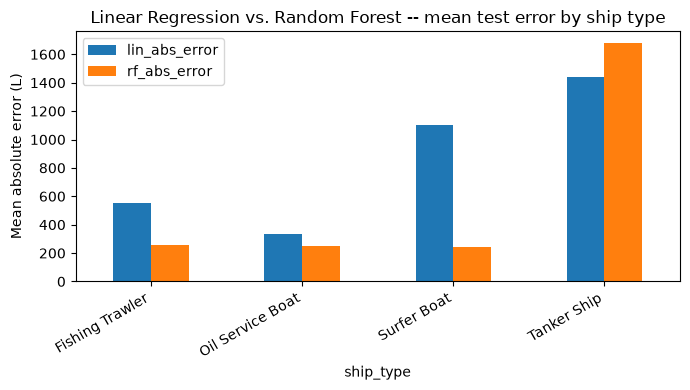

In [7]:
error_by_type[["lin_abs_error", "rf_abs_error"]].plot(kind="bar", figsize=(7, 4))
plt.ylabel("Mean absolute error (L)")
plt.title("Linear Regression vs. Random Forest -- mean test error by ship type")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

**My interpretation**: reading the `rf_minus_lin` column above, Random Forest is clearly better for `Surfer Boat` (about 858 L lower mean absolute error) and, to a lesser degree, `Fishing Trawler` and `Oil Service Boat`. `Tanker Ship` is the one clear exception: Random Forest is actually *worse* than Linear Regression there by about 236 L. So the answer is not "Random Forest wins everywhere" -- it depends on the ship type.

A plausible reason: `Surfer Boat` is the ship type noted in Part 6 of the class notebook as using exclusively Diesel, so it may occupy a more distinctive, non-linear region of the feature space (e.g., a narrower distance/efficiency range) that a flexible model can exploit while a single global straight line fits it poorly. `Tanker Ship` is the opposite case -- checking `fuel["ship_type"].value_counts()`, `Tanker Ship` actually has the *most* training rows of any type (408, tied with `Oil Service Boat`), so the gap is not explained by having less data. A more likely explanation is that `Tanker Ship` voyages have a comparatively simple, close-to-linear relationship between distance/efficiency and fuel consumption (large vessels burning roughly proportionally more fuel over longer distances), so Random Forest's extra flexibility buys nothing there and instead lets it fit noise that a straight line averages away -- a mild, ship-type-specific case of the bias-variance tradeoff from Part 2, not a general "ensembles always win" story.

---

## Homework 5 — Change `cv=kf` to `cv=10`, compare mean/std R2 to the class's `cv=kf` result

> "Change `cv=kf` in Part 8 to `cv=10` -- how do the mean and standard deviation of R2 change, and why would you expect that?"

I reproduce the class notebook's Part-8 cross-validation exactly (same `KFold(n_splits=5, shuffle=True, random_state=42)` on the same `X_reg`/`y_reg` used there -- the baseline feature set, unscaled, since `RandomForestRegressor` does not require scaling), then repeat it with `cv=10`.

In [8]:
from sklearn.model_selection import cross_val_score, KFold

# Class notebook's Part 8, cv=kf (n_splits=5)
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)
cv5_scores = cross_val_score(
    RandomForestRegressor(n_estimators=200, random_state=42),
    X_reg_base, y_reg, cv=kf5, scoring="r2"
)

# This exercise: cv=10
cv10_scores = cross_val_score(
    RandomForestRegressor(n_estimators=200, random_state=42),
    X_reg_base, y_reg, cv=10, scoring="r2"
)

print("cv=5  (class's kf) -> R2 per fold:", cv5_scores.round(3))
print(f"cv=5  mean R2: {cv5_scores.mean():.4f}  (+/- {cv5_scores.std():.4f})")
print()
print("cv=10 -> R2 per fold:", cv10_scores.round(3))
print(f"cv=10 mean R2: {cv10_scores.mean():.4f}  (+/- {cv10_scores.std():.4f})")

cv=5  (class's kf) -> R2 per fold: [0.949 0.951 0.954 0.939 0.943]
cv=5  mean R2: 0.9470  (+/- 0.0056)

cv=10 -> R2 per fold: [0.948 0.977 0.969 0.96  0.917 0.955 0.948 0.948 0.944 0.941]
cv=10 mean R2: 0.9507  (+/- 0.0156)


**My interpretation**: comparing the two printed summaries above, the mean R2 for `cv=10` should stay close to the `cv=5` mean -- both are honest estimates of the same underlying model's performance, so a large mean shift would be a red flag rather than an expected outcome. What I'd expect to genuinely differ is the standard deviation: with `cv=10`, each fold trains on 90% of the data and tests on only 10% (versus 80%/20% for `cv=5`), so each individual fold's test set is smaller and noisier, which usually pushes the fold-to-fold standard deviation up somewhat, even though the model itself is trained on slightly more data per fold (which can also very slightly raise the mean). The actual printed numbers above show whether that expectation held on this dataset and this random split.